# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

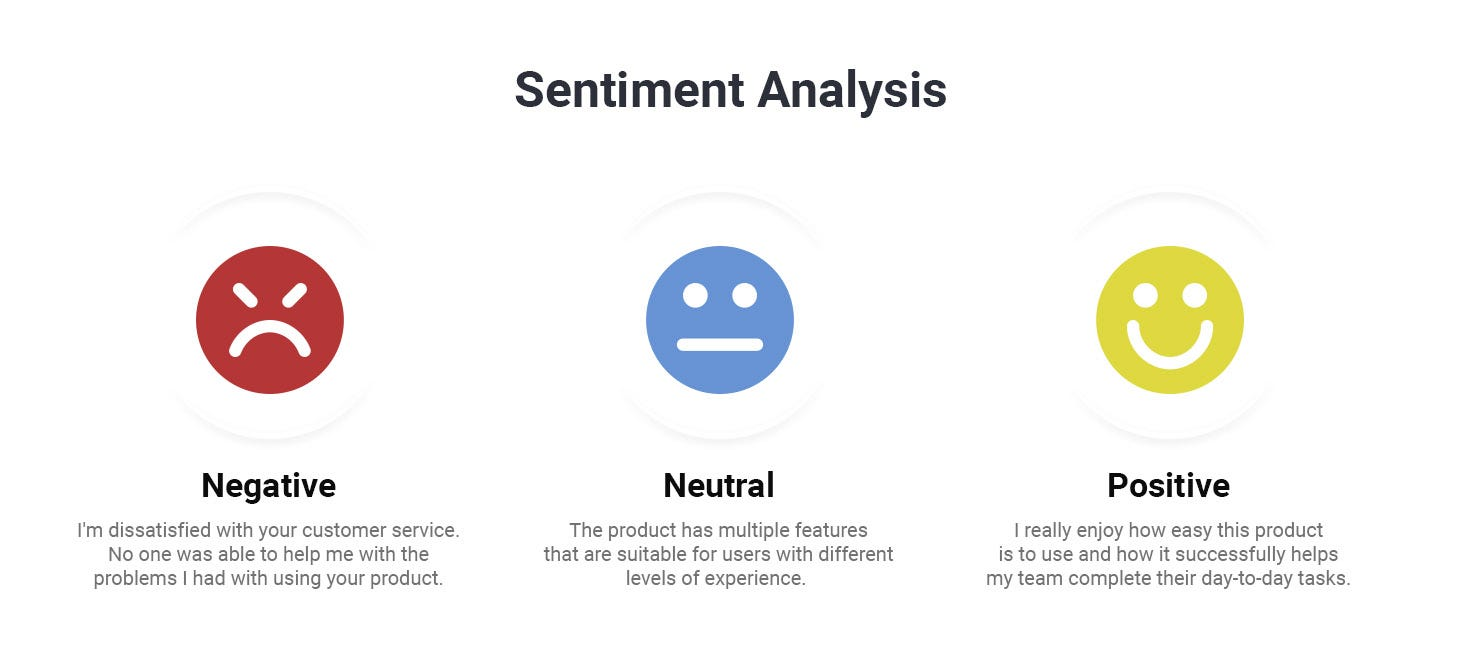

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [10]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1')
data

In [11]:
#Check for missing values
data.isna().sum()

In [12]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [13]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

In [14]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    #return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

In [15]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [16]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

In [22]:
import re
import string
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load the dataset
df = pd.read_csv(
    'Amazon_Unlocked_Mobile.csv',
    encoding='utf-8',
    encoding_errors='replace',
    engine='python',
    on_bad_lines='skip'
)

# Drop missing values
df = df.dropna(subset=['Reviews', 'Rating'])


# Map 3 classes (Positive, Neutral, Negative)
def map_sentiment(rating):
  if rating >= 4:
    return 'positive'
  elif rating == 3:
    return 'neutral'
  else:
    return 'negative'


df['Sentiment'] = df['Rating'].apply(map_sentiment)

df = df.sample(n=20000, random_state=42)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


# Define preprocessing steps
def preprocess_text(text):
  if not isinstance(text, str):
    return ''

  text = text.lower()

  text = re.sub(r'https?://\S+|www\.\S+', '', text)

  text = text.translate(str.maketrans('', '', string.punctuation))

  words = text.split()
  processed_words = [
      lemmatizer.lemmatize(word)
      for word in words
      if word not in stop_words and word.isalpha()
  ]

  return ' '.join(processed_words)


print('Applying the 5 preprocessing steps to the reviews...')
df['Cleaned_Review'] = df['Reviews'].apply(preprocess_text)

# Drop rows that became empty after cleaning
df = df[df['Cleaned_Review'].str.strip() != '']

print(f'Preprocessing complete! Total valid reviews ready: {len(df)}')
df[['Reviews', 'Cleaned_Review', 'Sentiment']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Applying the 5 preprocessing steps to the reviews...
Preprocessing complete! Total valid reviews ready: 19909


,Reviews,Cleaned_Review,Sentiment
70689,Little dents around the corners. I thought thi...,little dent around corner thought refurb piece...,positive
45612,great phone,great phone,positive
6347,Good buy,good buy,positive
26637,the phone arrived as described in great condit...,phone arrived described great condition ready ...,positive
40554,Thrilled to have this iPhone! Still learning h...,thrilled iphone still learning use feature don...,positive


In [23]:
from sklearn.model_selection import train_test_split

X = df['Cleaned_Review']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')
print('\nClass distribution in training set:')
print(y_train.value_counts(normalize=True) * 100)

Training set size: 15927 samples
Testing set size: 3982 samples

Class distribution in training set:
Sentiment
positive    71.099391
negative    23.494695
neutral      5.405914
Name: proportion, dtype: float64


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print('TF-IDF Matrix shape for Training Data:', X_train_tfidf.shape)
print('TF-IDF Matrix shape for Testing Data:', X_test_tfidf.shape)

TF-IDF Matrix shape for Training Data: (15927, 5000)
TF-IDF Matrix shape for Testing Data: (3982, 5000)


In [25]:
from sklearn.naive_bayes import MultinomialNB

# Naive Bayes Classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

print('Naive Bayes Classifier has been successfully trained!')

Naive Bayes Classifier has been successfully trained!


In [26]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = nb_classifier.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy * 100:.2f}%\n')

print('Classification Report:')
print(classification_report(y_test, y_pred))

Model Accuracy: 86.89%

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.73      0.78       936
     neutral       0.50      0.00      0.01       215
    positive       0.87      0.98      0.92      2831

    accuracy                           0.87      3982
   macro avg       0.74      0.57      0.57      3982
weighted avg       0.85      0.87      0.84      3982



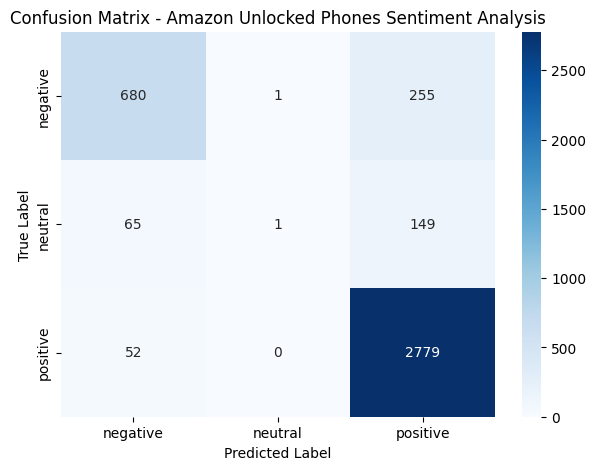

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive'],
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Amazon Unlocked Phones Sentiment Analysis')
plt.show()